## 0. Config

In [201]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder
import torch.optim as optim
import matplotlib.pyplot as plt

In [189]:
random_state = 123
torch.manual_seed(random_state)
np.random.seed(random_state)

## 1. Data preparing

In [63]:
df = pd.read_csv("Train_rev1.csv")
df.head()

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName
0,12612628,Engineering Systems Analyst,Engineering Systems Analyst Dorking Surrey Sal...,"Dorking, Surrey, Surrey",Dorking,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk
1,12612830,Stress Engineer Glasgow,Stress Engineer Glasgow Salary **** to **** We...,"Glasgow, Scotland, Scotland",Glasgow,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 35000/annum 25-35K,30000,cv-library.co.uk
2,12612844,Modelling and simulation analyst,Mathematical Modeller / Simulation Analyst / O...,"Hampshire, South East, South East",Hampshire,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 40000/annum 20-40K,30000,cv-library.co.uk
3,12613049,Engineering Systems Analyst / Mathematical Mod...,Engineering Systems Analyst / Mathematical Mod...,"Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 30000/annum 25K-30K negotiable,27500,cv-library.co.uk
4,12613647,"Pioneer, Miser Engineering Systems Analyst","Pioneer, Miser Engineering Systems Analyst Do...","Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk


In [64]:
cat_features = ["Category", "Company", "LocationNormalized", "ContractType", "ContractTime"]
df_cat = df[cat_features + ["SalaryNormalized"]].copy()
df_cat.head()

,Category,Company,LocationNormalized,ContractType,ContractTime,SalaryNormalized
0,Engineering Jobs,Gregory Martin International,Dorking,NaN,permanent,25000
1,Engineering Jobs,Gregory Martin International,Glasgow,NaN,permanent,30000
2,Engineering Jobs,Gregory Martin International,Hampshire,NaN,permanent,30000
3,Engineering Jobs,Gregory Martin International,Surrey,NaN,permanent,27500
4,Engineering Jobs,Gregory Martin International,Surrey,NaN,permanent,25000


In [65]:
print(df_cat.isna().sum())
for column in cat_features:
    df_cat[column] = df_cat[column].fillna("Missing").astype(str)

Category                   0
Company                32430
LocationNormalized         0
ContractType          179326
ContractTime           63905
SalaryNormalized           0
dtype: int64


In [138]:
label_encoders = {}
for col in cat_features:
    le = LabelEncoder()
    df_cat[col] = le.fit_transform(df_cat[col])
    label_encoders[col] = le
df_cat[cat_features] = df_cat[cat_features]+1
df_cat.head()

,Category,Company,LocationNormalized,ContractType,ContractTime,SalaryNormalized
0,9,7758,751,1,3,25000
1,9,7758,987,1,3,30000
2,9,7758,1069,1,3,30000
3,9,7758,2310,1,3,27500
4,9,7758,2310,1,3,25000


(array([8.18240e+04, 1.06594e+05, 3.91120e+04, 1.18100e+04, 5.13200e+03,
        9.60000e+01, 9.70000e+01, 5.60000e+01, 2.80000e+01, 1.90000e+01]),
 array([  5000.,  24500.,  44000.,  63500.,  83000., 102500., 122000.,
        141500., 161000., 180500., 200000.]),
 <BarContainer object of 10 artists>)

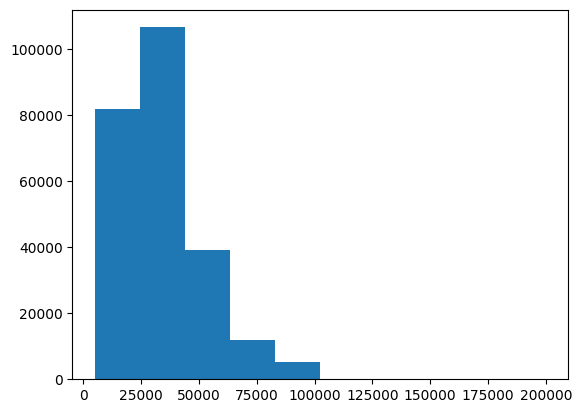

In [226]:
plt.hist(df_cat.SalaryNormalized)

In [203]:
x_train_cat, x_test_cat, y_train_cat, y_test_cat = train_test_split(df_cat.drop("SalaryNormalized", axis=1), np.log1p(df_cat.SalaryNormalized), test_size=0.2, random_state=random_state)

In [204]:
class JobSalaryDataset:
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.long)
        self.y = torch.tensor(y.values.reshape(-1,1), dtype=torch.float32)

    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
train_dataset = JobSalaryDataset(x_train_cat, y_train_cat)
test_dataset = JobSalaryDataset(x_test_cat, y_test_cat)

In [205]:
# example row
print("First row:","\nx = ", train_dataset[0][0], "\ny = ", train_dataset[0][1])

First row: 
x =  tensor([  12, 8362, 1457,    2,    1]) 
y =  tensor([10.2103])


In [206]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## 2. Baseline

In [216]:
class BaselineModel(nn.Module):
    def __init__(self, vocab_size, emb_dim=16):
        super(BaselineModel, self).__init__()
        
        self.embedding = nn.ModuleList([nn.Embedding(num_embeddings=size, embedding_dim=emb_dim, padding_idx=0) for size in vocab_size])
        input_dim = len(vocab_size) * emb_dim
        
        self.fc1 = nn.Linear(input_dim, 128)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(64, 16)
        self.relu3 = nn.ReLU()

        self.out = nn.Linear(16,1)

    def forward(self, x):
        embedding_list = [layer(x[:,i]) for i, layer in enumerate(self.embedding)]
        x = torch.cat(embedding_list, dim = 1)

        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.relu3(self.fc3(x))
        x = self.out(x)
        return x        

In [224]:
vocab_size = [np.max(df_cat.iloc[:,col]) + 1 for col in range(len(df_cat.columns)-1)]
print("vocab = ",vocab_size)
baseline = BaselineModel(vocab_size)

vocab =  [np.int64(30), np.int64(20814), np.int64(2733), np.int64(4), np.int64(4)]


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline.to(device)

def fit(model, train, valid, loss=nn.MSELoss(), epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    optimizer = optim.Adam(model.parameters())
    train_loss = []
    valid_loss = []

    for epoch in range(epochs):
        train_sum_loss = 0
        model.train()
        
        for batch_x, batch_y in train:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            preds = model(batch_x)
            l = loss(preds, batch_y)
            l.backward()
            optimizer.step()

            train_sum_loss += l.item() * batch_x.size(0)
        train_loss.append(train_sum_loss / len(train.dataset))
        print("Train loss at epoch",epoch,":", train_loss[-1])

        model.eval()
        valid_sum_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in valid:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                preds = model(batch_x)
                l = loss(preds, batch_y)
                valid_sum_loss += l.item() * batch_x.size(0)

        valid_loss.append(valid_sum_loss / len(valid.dataset))
        print("Valid loss at epoch",epoch,":", valid_loss[-1])


fit(baseline, train_loader, test_loader)

Train loss at epoch 0 : 1.07808020196557
Valid loss at epoch 0 : 0.1888737937759456
Train loss at epoch 1 : 0.1673484427423758
Valid loss at epoch 1 : 0.16818288957602195
Train loss at epoch 2 : 0.15529684176005534
Valid loss at epoch 2 : 0.151713857998201
Train loss at epoch 3 : 0.14465674502829465
Valid loss at epoch 3 : 0.1557962198029421
Train loss at epoch 4 : 0.137570245540576
Valid loss at epoch 4 : 0.13907579480859
Train loss at epoch 5 : 0.1313227985202989
Valid loss at epoch 5 : 0.1378369111096386
Train loss at epoch 6 : 0.12596872070604878
Valid loss at epoch 6 : 0.134513482249932
Train loss at epoch 7 : 0.12252164274586223
Valid loss at epoch 7 : 0.1836462191412173
Train loss at epoch 8 : 0.11850925369388386
Valid loss at epoch 8 : 0.13018024271768736
Train loss at epoch 9 : 0.1158280017972997
Valid loss at epoch 9 : 0.13252874493596503
